In [2]:
# use reload extension
%load_ext autoreload
%autoreload 1

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:

import sys, os
# Ensure project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: /home/nguyen/projects/SPFSplatV2


## 1. Manually construct config & dataset (no Hydra)

In [7]:
from pathlib import Path
from src.dataset.dataset_famos import DatasetFaMOS, DatasetFaMoSCfg
from src.dataset.view_sampler.view_sampler_all import ViewSamplerAll, ViewSamplerAllCfg

# ---------- Adjust these paths to match your setup ----------
FAMOS_ROOT = Path('/media/nguyen/FaMoS')  # relative to PROJECT_ROOT, or use absolute path
# If your images are a different resolution, update original_image_shape accordingly.
# --------------------------------------------------------------

# Build dataset config manually (mirrors famos.yaml + base_dataset.yaml)
cfg = DatasetFaMoSCfg(
    # --- from base_dataset.yaml ---
    original_image_shape=[1024, 1280],   # <-- adjust to your actual image H, W
    input_image_shape=[256, 256],
    background_color=[0.0, 0.0, 0.0],
    cameras_are_circular=False,
    overfit_to_scene=None,
    # --- view sampler (using 'all' for simplicity) ---
    view_sampler=ViewSamplerAllCfg(name='all'),
    # --- famos-specific ---
    name='famos',
    data_root=FAMOS_ROOT,
    baseline_min=1e-3,
    baseline_max=1e10,
    max_fov=100.0,
    make_baseline_1=False,   # set False for quick test -- no baseline filtering
    augment=False,           # no augmentation for test
    relative_pose=False,     # keep absolute poses for inspection
    skip_bad_shape=False,    # don't skip -- we want to see what shapes we get
    load_stereo=True,
    load_color=True,
    image_resize_factor=1.0,
    near=0.1,
    far=100.0,
)

print('Config created OK')
print(f'  data_root: {cfg.data_root}')

Config created OK
  data_root: /media/nguyen/FaMoS


In [8]:
# Create a simple 'all' view sampler (returns all views as both context and target)
view_sampler = ViewSamplerAll(
    cfg=ViewSamplerAllCfg(name='all'),
    stage='train',
    is_overfitting=False,
    cameras_are_circular=False,
    step_tracker=None,
)

# Instantiate the dataset
dataset = DatasetFaMOS(cfg=cfg, stage='train', view_sampler=view_sampler)
print(f'Dataset created OK — {len(dataset)} samples')

Dataset created OK — 88478 samples


## 2. Load a single sample and inspect

In [9]:
sample = dataset[0]

print('=== Sample keys ===')
print(list(sample.keys()))
print(f"\nScene: {sample['scene']}")

print('\n=== Context ===')
for k, v in sample['context'].items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}  dtype={v.dtype}')
    else:
        print(f'  {k}: {v}')

print('\n=== Target ===')
for k, v in sample['target'].items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}  dtype={v.dtype}')
    else:
        print(f'  {k}: {v}')

=== Sample keys ===
['context', 'target', 'scene']

Scene: FaMoS_subject_005/anger/000071

=== Context ===
  extrinsics: torch.Size([24, 4, 4])  dtype=torch.float32
  intrinsics: torch.Size([24, 3, 3])  dtype=torch.float32
  image: torch.Size([24, 3, 256, 256])  dtype=torch.float32
  near: torch.Size([24])  dtype=torch.float32
  far: torch.Size([24])  dtype=torch.float32
  index: torch.Size([24])  dtype=torch.int64
  overlap: torch.Size([1])  dtype=torch.float32

=== Target ===
  extrinsics: torch.Size([24, 4, 4])  dtype=torch.float32
  intrinsics: torch.Size([24, 3, 3])  dtype=torch.float32
  image: torch.Size([24, 3, 256, 256])  dtype=torch.float32
  near: torch.Size([24])  dtype=torch.float32
  far: torch.Size([24])  dtype=torch.float32
  index: torch.Size([24])  dtype=torch.int64


## 3. Visualise context images

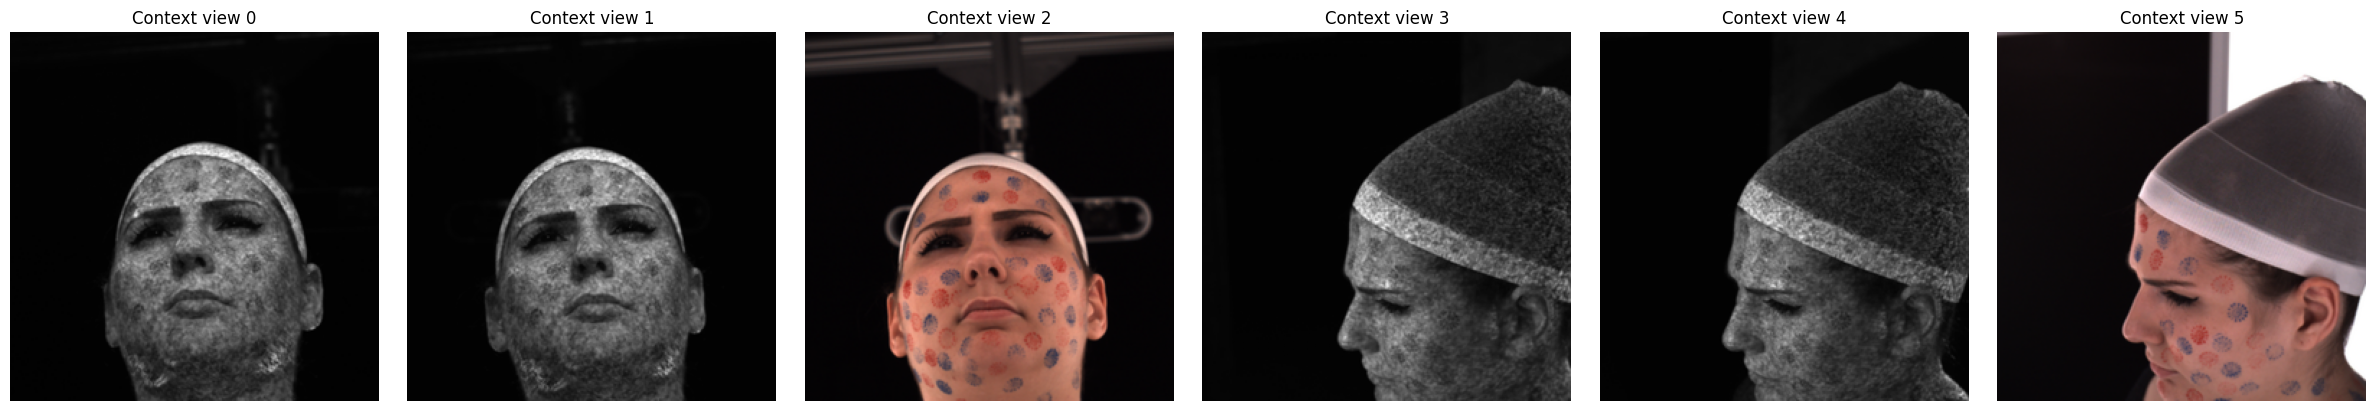

In [10]:
import matplotlib.pyplot as plt

ctx_imgs = sample['context']['image']  # (V, 3, H, W)
n = min(ctx_imgs.shape[0], 6)  # show up to 6 views

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for i in range(n):
    img = ctx_imgs[i].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f'Context view {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 4. Test with Hydra config (optional)

If you want to test loading via the Hydra config pipeline instead:

In [ ]:
from omegaconf import OmegaConf
from src.dataset import get_dataset, DatasetCfgWrapper
from dacite import Config, from_dict

# Load the YAML files and compose them
base_cfg = OmegaConf.load(os.path.join(PROJECT_ROOT, 'config/dataset/base_dataset.yaml'))
famos_cfg = OmegaConf.load(os.path.join(PROJECT_ROOT, 'config/dataset/famos.yaml'))
vs_cfg = OmegaConf.load(os.path.join(PROJECT_ROOT, 'config/dataset/view_sampler/bounded.yaml'))

# Merge: base -> famos, then inject view_sampler
merged = OmegaConf.merge(base_cfg, famos_cfg)
merged['view_sampler'] = vs_cfg

print('Composed Hydra config:')
print(OmegaConf.to_yaml(merged))

In [ ]:
# Parse into typed config wrapper
wrapper_dict = {'famos': OmegaConf.to_container(merged, resolve=True)}

from src.config import load_typed_config
from src.dataset.dataset_famos import DatasetFaMoSCfgWrapper

cfg_wrapper = load_typed_config(
    OmegaConf.create(wrapper_dict),
    DatasetFaMoSCfgWrapper,
)
print(f'Typed config: {cfg_wrapper}')

# Create dataset through the standard pipeline
datasets = get_dataset(cfg_wrapper, stage='train', step_tracker=None)
ds = datasets[0]
print(f'\nDataset length: {len(ds)}')
print(f'Sample 0 scene: {ds[0]["scene"]}')

## 5. Test with DataLoader (batching)

In [ ]:
from torch.utils.data import DataLoader

# Use dataset from section 2 (the 'all' sampler one)
loader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

batch = next(iter(loader))
print('Batch keys:', list(batch.keys()))
print(f"Context images: {batch['context']['image'].shape}")  # (B, V, 3, H, W)
print(f"Context extrinsics: {batch['context']['extrinsics'].shape}")  # (B, V, 4, 4)
print(f"Context intrinsics: {batch['context']['intrinsics'].shape}")  # (B, V, 3, 3)
print(f"Target images: {batch['target']['image'].shape}")